# 3D Nanotube Visualization (MuMax3 hollow cylinder)

Reads output from `nanotube_3D.mx3` — a hollow cylinder with perpendicular DMI and radial field.

**Key:** the `.ovf` files now contain a full 3D vector field on the cuboid grid.
Cells outside the nanotube shell have `Msat=0` and will show `m=(0,0,0)` — mask them out before plotting.

In [2]:
import discretisedfield as df
import ubermagtable as ut
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob, os

SIM_DIR = './nanotube_3D.out'
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, 'm*.ovf')))
print(f'Found {len(ovf_files)} snapshots')

# Load the final saved state (named m_final.ovf)
final_path = os.path.join(SIM_DIR, 'm_final.ovf')
field = df.Field.from_file(final_path)
print('Field shape:', field.mesh.n)
print('Cell size:  ', field.mesh.cell)

Found 3 snapshots
Field shape: [20 20 80]
Cell size:   [2.e-09 2.e-09 2.e-09]


## 1. Cross-Section Slices (xy plane at different z)

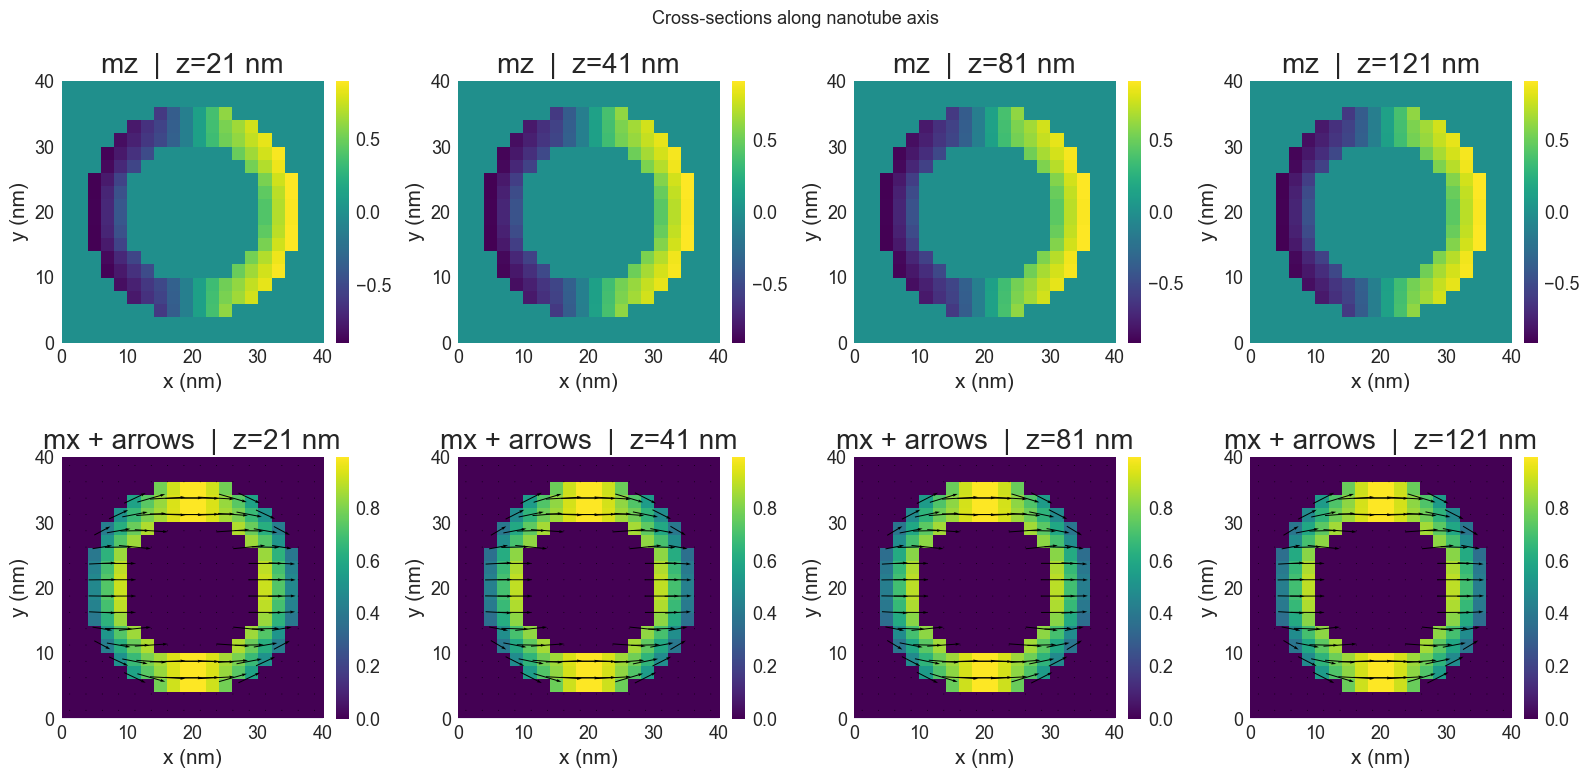

In [16]:
# Show 4 cross-sections along the nanotube axis
Nz = field.mesh.n[2]
z_indices = [Nz//8, Nz//4, Nz//2, 3*Nz//4]
z_coords = [field.mesh.region.pmin[2] + (i + 0.5) * field.mesh.cell[2] for i in z_indices]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (iz, zc) in enumerate(zip(z_indices, z_coords)):
    ax_top = axes[0][col]
    field.sel(z=zc).z.mpl.scalar(ax=ax_top, cmap='viridis', colorbar=True)   
    ax_top.set_title(f'mz  |  z={zc*1e9:.0f} nm')

    ax_bot = axes[1][col]
    field.sel(z=zc).x.mpl.scalar(ax=ax_bot, cmap='viridis', colorbar=True)   
    field.sel(z=zc).resample(n=(16, 16)).mpl.vector(                       
        ax=ax_bot, use_color=False, color='black')
    ax_bot.set_title(f'mx + arrows  |  z={zc*1e9:.0f} nm')

plt.suptitle('Cross-sections along nanotube axis', fontsize=13)
plt.tight_layout()
plt.savefig('NT_cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Longitudinal Slice (xz plane at y=0)

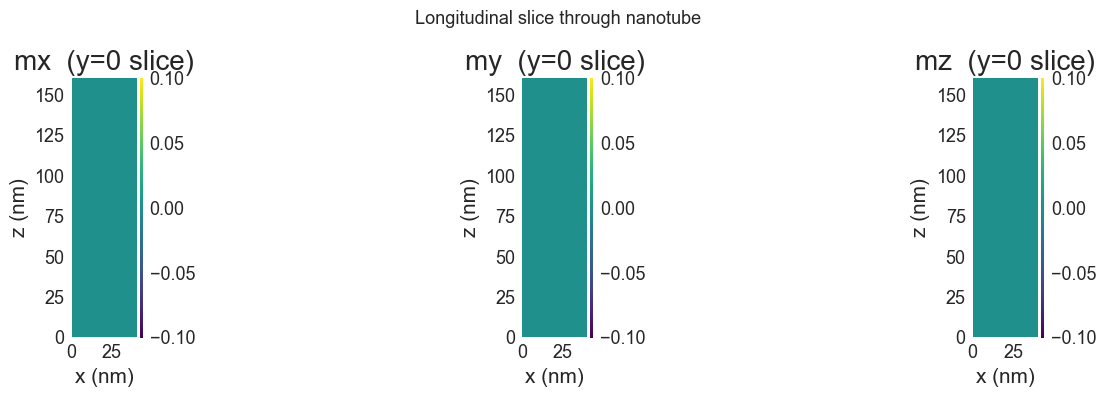

In [17]:
# Slice through the middle of the tube (y=0)
y_mid = 0.0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, comp in zip(axes, ['x', 'y', 'z']):
    getattr(field.sel(y=y_mid), comp).mpl.scalar(ax=ax, cmap='viridis', colorbar=True)  
    ax.set_title(f'm{comp}  (y=0 slice)')

plt.suptitle('Longitudinal slice through nanotube', fontsize=13)
plt.tight_layout()
plt.savefig('NT_longitudinal.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 3D Interactive Visualization (k3d)

In [11]:
# Full 3D cone plot — works in Jupyter notebook with k3d installed
# pip install k3d
try:
    import k3d
    # Vector field (3D cones)
    #field.k3d.vector()
    #Scalar field (3D volume) but exclude the large empty space outside the tube
    field.x.k3d.scalar(filter_field=field.norm)
    #field.z.k3d.scalar()
except ImportError:
    print('k3d not installed: pip install k3d')

Output()

## 4. Azimuthal Profile: spin texture around the ring

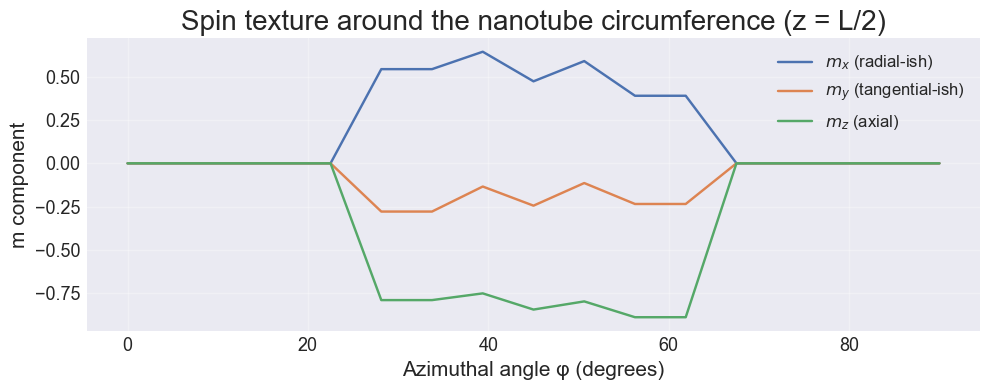

In [14]:
# Sample the field along the circumference of the nanotube
# at z=L/2 (middle) and r = (R_in + R_out)/2 (mid-shell)
R_out = 16e-9
R_in  = 11e-9
r_mid = (R_out + R_in) / 2
z_mid = (field.mesh.region.pmin[2] + field.mesh.region.pmax[2]) / 2
N_phi = 64
phi = np.linspace(0, 2*np.pi, N_phi, endpoint=False)

mx_phi, my_phi, mz_phi = [], [], []
for p in phi:
    xp = r_mid * np.cos(p)
    yp = r_mid * np.sin(p)
    try:
        val = field((xp, yp, z_mid))  # interpolate at point
        mx_phi.append(val[0])
        my_phi.append(val[1])
        mz_phi.append(val[2])
    except Exception:
        mx_phi.append(np.nan)
        my_phi.append(np.nan)
        mz_phi.append(np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.degrees(phi), mx_phi, label=r'$m_x$ (radial-ish)')
ax.plot(np.degrees(phi), my_phi, label=r'$m_y$ (tangential-ish)')
ax.plot(np.degrees(phi), mz_phi, label=r'$m_z$ (axial)')
ax.set_xlabel('Azimuthal angle φ (degrees)')
ax.set_ylabel('m component')
ax.set_title('Spin texture around the nanotube circumference (z = L/2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NT_azimuthal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Scalar Data Table

In [ ]:
table = ut.Table.fromfile(os.path.join(SIM_DIR, 'table.txt'), x='t')
print('Columns:', table.data.columns.tolist())

# Plot all magnetization components during relaxation
table.mpl(y=['mx', 'my', 'mz'])
plt.title('Relaxation — average magnetization vs. time')
plt.tight_layout()
plt.show()

## Notes

| Parameter | Value | Meaning |
|---|---|---|
| `R_out` | 16 nm | Outer radius |
| `R_in` | 11 nm | Inner radius (shell thickness = 5 nm) |
| `L` | 160 nm | Nanotube length |
| `cell` | 2 nm | ~2.5 cells across shell |
| `Dind` | 5×10⁻³ J/m² | Perpendicular DMI (strong regime) |
| `B_ext` | 1 T along x | Radial field (uniform approximation) |

**True radial field:** uncomment the `B_ext.SetFunction(...)` lines in the `.mx3`
script to apply a spatially-varying radial field B(r) = B₀ · r̂.